# Image Processing

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import skimage as ski

from pathlib import Path

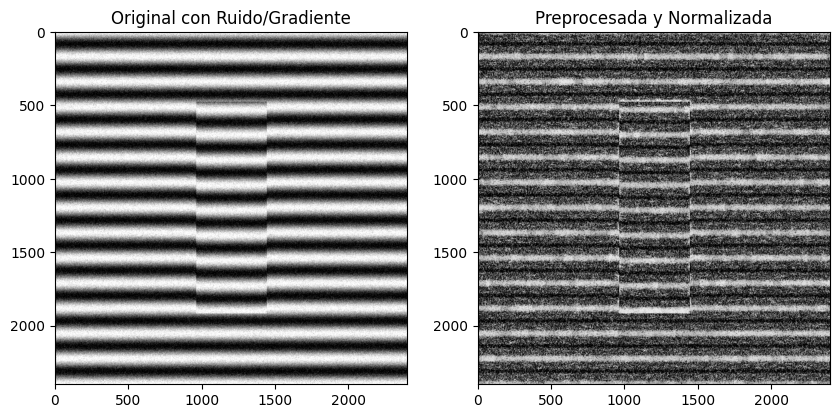

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage


# En VS Code Jupyter, Path.cwd() apunta a la carpeta donde está este notebook (ej. 'notebooks/')
notebook_path = Path.cwd()

# Subimos un nivel a la raíz del proyecto para luego entrar a 'data/01_raw'
root_path = notebook_path.parent
images_path = root_path / "data" / "01_raw"

file_name = "block_2.5_mm(simulated).png"
complete_path = images_path / file_name

# ==========================================
# PASO 1: CARGA Y SEGMENTACIÓN DE ROI
# ==========================================
# Cargar el interferograma en escala de grises (matriz 2D)
img = cv2.imread(str(complete_path), cv2.IMREAD_GRAYSCALE)

# Suponiendo dimensiones conocidas para el bloque patrón central (coordenadas de ejemplo)
# En un sistema automatizado, estas máscaras se definen por umbralización o bordes
# Asegurarse de que la imagen se haya cargado; si no, intentar la lectura robusta con np.fromfile (evita problemas con tildes)
if img is None:
    try:
        img_array = np.fromfile(complete_path, np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
    except Exception:
        img = None

if img is None:
    raise IOError(f"Failed to load image from: {complete_path}")

h, w = img.shape
mascara_bloque = np.zeros((h, w), dtype=np.uint8)
mascara_platina = np.zeros((h, w), dtype=np.uint8)

# Ejemplo: Definir el rectángulo del bloque (reducido unos píxeles para evitar bordes/biseles)
# mascara_bloque[y_min+5:y_max-5, x_min+5:x_max-5] = 255
# mascara_platina[regiones_laterales] = 255

# ==========================================
# PASO 2: CORRECCIÓN DE FONDO (TOP-HAT)
# ==========================================
# Se usa un elemento estructurante circular mayor al ancho de una franja
# para estimar y eliminar el perfil de iluminación del haz láser (componente DC)
tamanio_kernel = 50  # Ajustar según el ancho de la franja en píxeles
kernel_morf = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (tamanio_kernel, tamanio_kernel))

# Operación Top-Hat: Resta la apertura morfológica de la imagen original
img_flat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel_morf)

# ==========================================
# PASO 3: FILTRADO DE RUIDO (PRESERVANDO BORDES)
# ==========================================
# El filtro de mediana de SciPy es ideal para speckle y ruido de alta frecuencia
# sin alterar la posición espacial de los máximos y mínimos de interferencia
img_filtrada = ndimage.median_filter(img_flat, size=5)

# ==========================================
# PASO 4: MEJORA DE CONTRASTE ADAPTATIVO (CLAHE)
# ==========================================
# Twyman-Green a menudo presenta diferente reflectividad entre el acero del bloque
# y la platina. CLAHE ecualiza localmente para homogeneizar el contraste.
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_filtrada)

# ==========================================
# PASO 5: NORMALIZACIÓN FINAL
# ==========================================
# Convertir a flotante y acotar estrictamente entre 0.0 y 1.0 para el cálculo de fase
img_preprocesada = img_clahe.astype(np.float64) / 255.0

# Aplicar las máscaras para separar los datos analíticos
interferograma_bloque = cv2.bitwise_and(img_preprocesada, img_preprocesada, mask=mascara_bloque)
interferograma_platina = cv2.bitwise_and(img_preprocesada, img_preprocesada, mask=mascara_platina)

# Visualización del resultado intermedio
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original con Ruido/Gradiente")
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Preprocesada y Normalizada")
plt.imshow(img_preprocesada, cmap='gray')
plt.show()